In [3]:
import pandas as pd


df = pd.read_csv('/content/Imdb Movies Dataset.csv', on_bad_lines='skip')
df_aux = df.copy()

df.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
5,293660,Deadpool,7.606,28894,Released,2/9/2016,783100000,108,False,58000000,...,en,Deadpool,The origin story of former Special Forces oper...,72.735,Witness the beginning of a happy ending.,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,English,"superhero, anti hero, mercenary, based on comi..."
6,299536,Avengers: Infinity War,8.255,27713,Released,4/25/2018,2052415039,149,False,300000000,...,en,Avengers: Infinity War,As the Avengers and their allies have continue...,154.340,An entire universe. Once and for all.,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s..."
7,550,Fight Club,8.438,27238,Released,10/15/1999,100853753,139,False,63000000,...,en,Fight Club,A ticking-time-bomb insomniac and a slippery s...,69.498,Mischief. Mayhem. Soap.,Drama,"Regency Enterprises, Fox 2000 Pictures, Taurus...",United States of America,English,"dual identity, rage and hate, based on novel o..."
8,118340,Guardians of the Galaxy,7.906,26638,Released,7/30/2014,772776600,121,False,170000000,...,en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",33.255,All heroes start somewhere.,"Action, Science Fiction, Adventure",Marvel Studios,United States of America,English,"spacecraft, based on comic, space, orphan, adv..."
9,680,Pulp Fiction,8.488,25893,Released,9/10/1994,213900000,154,False,8500000,...,en,Pulp Fiction,"A burger-loving hit man, his philosophical par...",74.862,Just because you are a character doesn't mean ...,"Thriller, Crime","Miramax, A Band Apart, Jersey Films",United States of America,"English, Spanish, French","drug dealer, boxer, massage, stolen money, bri..."


In [46]:
# Exibe os nomes e tipos de dados das colunas da tabela
df.dtypes

,0
id,int64
title,object
vote_average,float64
vote_count,int64
status,object
release_date,object
revenue,int64
runtime,int64
adult,bool
budget,int64


In [61]:
#Top 20 filmes do Imdb ordenados por quantidade de votos e média de nota, exibindo seus gêneros

top_filmes = df_aux.sort_values(by=['vote_count', 'vote_average'], ascending=[False, False]).head(20)
top_filmes[['title', 'vote_average', 'vote_count', 'genres', 'popularity']]


,title,vote_average,vote_count,genres,popularity
0,Inception,8.364,34495,"Action, Science Fiction, Adventure",83.952
1,Interstellar,8.417,32571,"Adventure, Drama, Science Fiction",140.241
2,The Dark Knight,8.512,30619,"Drama, Action, Crime, Thriller",130.643
3,Avatar,7.573,29815,"Action, Adventure, Fantasy, Science Fiction",79.932
4,The Avengers,7.710,29166,"Science Fiction, Action, Adventure",98.082
5,Deadpool,7.606,28894,"Action, Adventure, Comedy",72.735
6,Avengers: Infinity War,8.255,27713,"Adventure, Action, Science Fiction",154.340
7,Fight Club,8.438,27238,Drama,69.498
8,Guardians of the Galaxy,7.906,26638,"Action, Science Fiction, Adventure",33.255
9,Pulp Fiction,8.488,25893,"Thriller, Crime",74.862


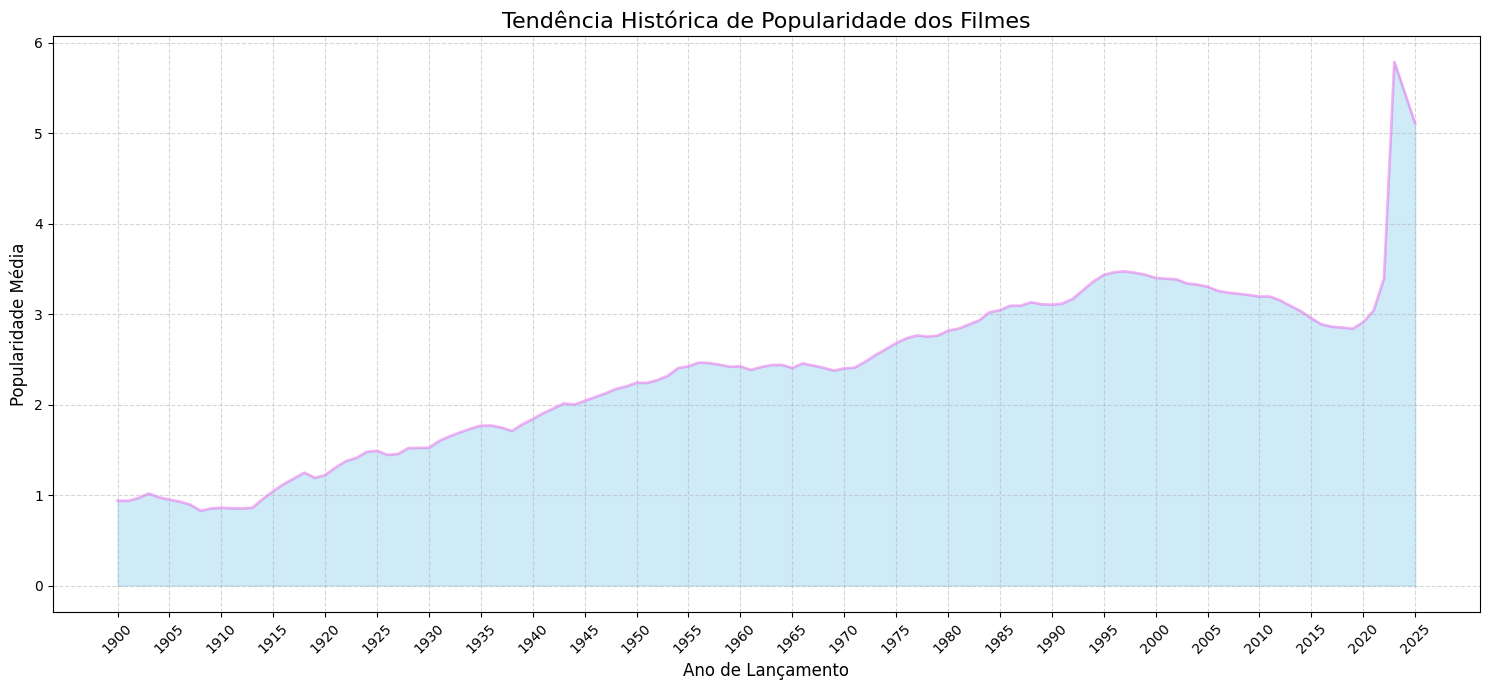

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

df_aux['release_year'] = pd.to_datetime(df_aux['release_date'], errors='coerce').dt.year
df_plot = df_aux.dropna(subset=['release_year']).copy()
df_plot['release_year'] = df_plot['release_year'].astype(int)

df_ano = df_plot.groupby('release_year')['popularity'].mean().reset_index()

df_ano['popularity_smooth'] = df_ano['popularity'].rolling(window=5, min_periods=1).mean()

# 4. Criação do Gráfico
plt.figure(figsize=(15, 7))

# Gráfico de área preenchida (mais moderno e legível)
plt.fill_between(df_ano['release_year'], df_ano['popularity_smooth'], color="skyblue", alpha=0.4)
plt.plot(df_ano['release_year'], df_ano['popularity_smooth'], color="violet", alpha=0.6, linewidth=2)

# Customização
plt.title('Tendência Histórica de Popularidade dos Filmes', fontsize=16)
plt.xlabel('Ano de Lançamento', fontsize=12)
plt.ylabel('Popularidade Média', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajuste do eixo X para não amontoar
plt.xticks(df_ano['release_year'][::5], rotation=45)

plt.tight_layout()
plt.show()

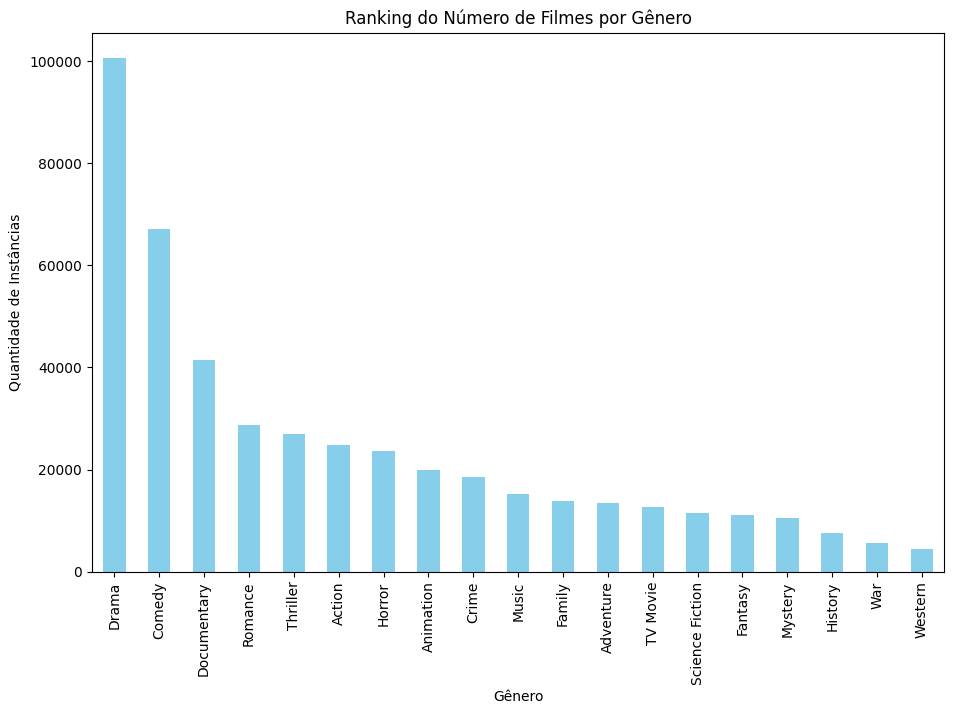

In [63]:
#Exibe os gêneros com maior número de instâncias
generos_limpos = df['genres'].str.split(',').explode().str.strip()

generos_limpos.value_counts().head(19).plot(kind='bar', figsize=(11,7), color='skyblue')

plt.title('Ranking do Número de Filmes por Gênero')
plt.ylabel('Quantidade de Instâncias')
plt.xlabel('Gênero')
plt.xticks(fontsize=10)
plt.show()

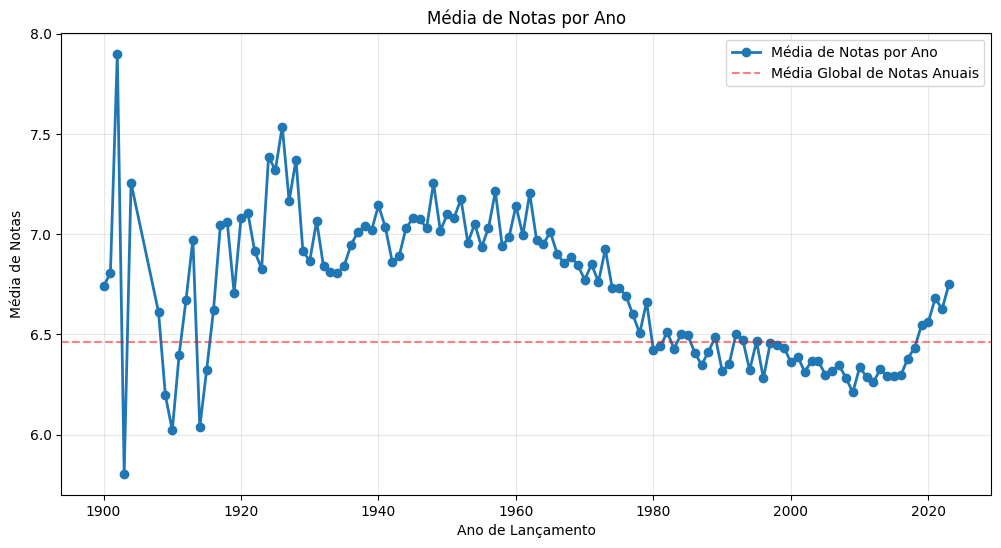

In [64]:
#Exibe um gráfico que representa a relação entre notas totais com média de notas para ano de lançamento
import matplotlib.pyplot as plt

minimo_votos = df_plot['vote_count'].mean()

df_filtrado = df_plot[df_plot['vote_count'] >= (minimo_votos - 12)]

plt.figure(figsize=(12, 6))
df_filtrado.groupby('release_year')['vote_average'].mean().plot(kind='line', marker='o',linewidth=2, label='Média de Notas por Ano')

plt.title(f'Média de Notas por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Média de Notas')
plt.grid(True, alpha=0.3)

plt.axhline(y=df_filtrado['vote_average'].mean(), color='red', linestyle='--', alpha=0.5, label='Média Global de Notas Anuais')
plt.legend(loc='best')

plt.show()

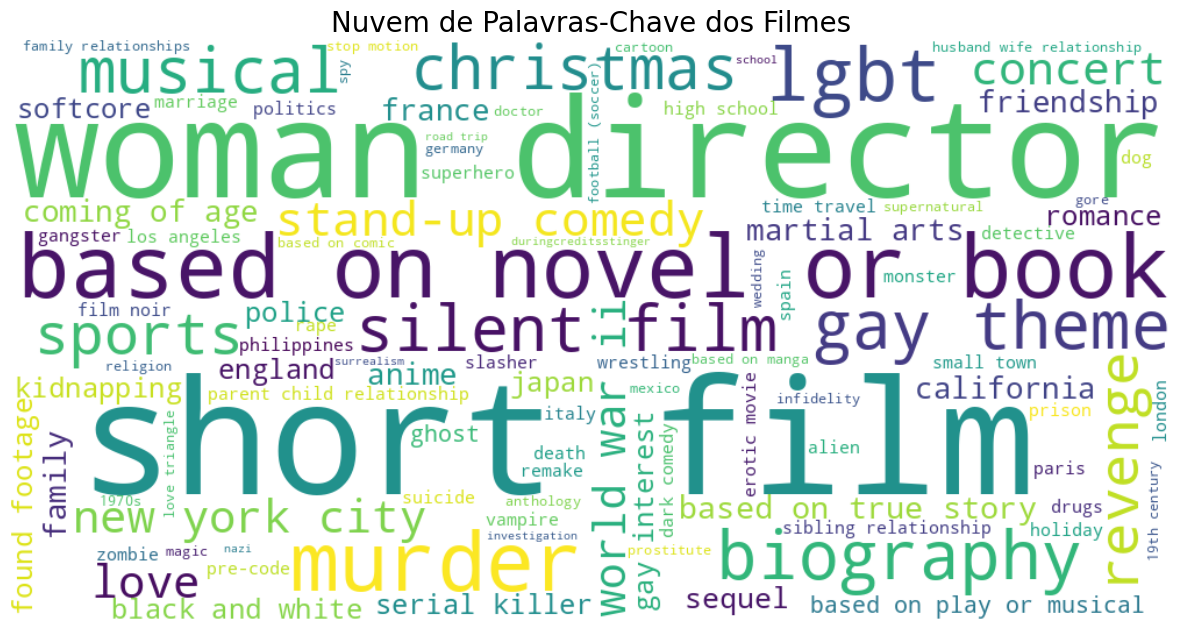

keywords
short film                   10903
woman director                9928
based on novel or book        4606
murder                        3940
lgbt                          3096
biography                     2568
gay theme                     2510
silent film                   2336
musical                       2286
christmas                     2119
sports                        1943
revenge                       1901
stand-up comedy               1885
concert                       1793
love                          1684
new york city                 1681
world war ii                  1632
based on true story           1573
anime                         1480
martial arts                  1429
coming of age                 1429
family                        1393
friendship                    1378
france                        1371
california                    1329
sequel                        1258
romance                       1181
england                       1157
serial kill

In [65]:
#Exibe um wordcloud que mostra a maior frequência de palavras-chave e lista as suas top 50
from wordcloud import WordCloud

keywords_series = df_aux['keywords'].dropna().str.split(',').explode().str.strip()


frequencia_keywords = keywords_series.value_counts().to_dict()

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate_from_frequencies(frequencia_keywords)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nuvem de Palavras-Chave dos Filmes', fontsize=20)
plt.show()

print(keywords_series.value_counts().head(50))

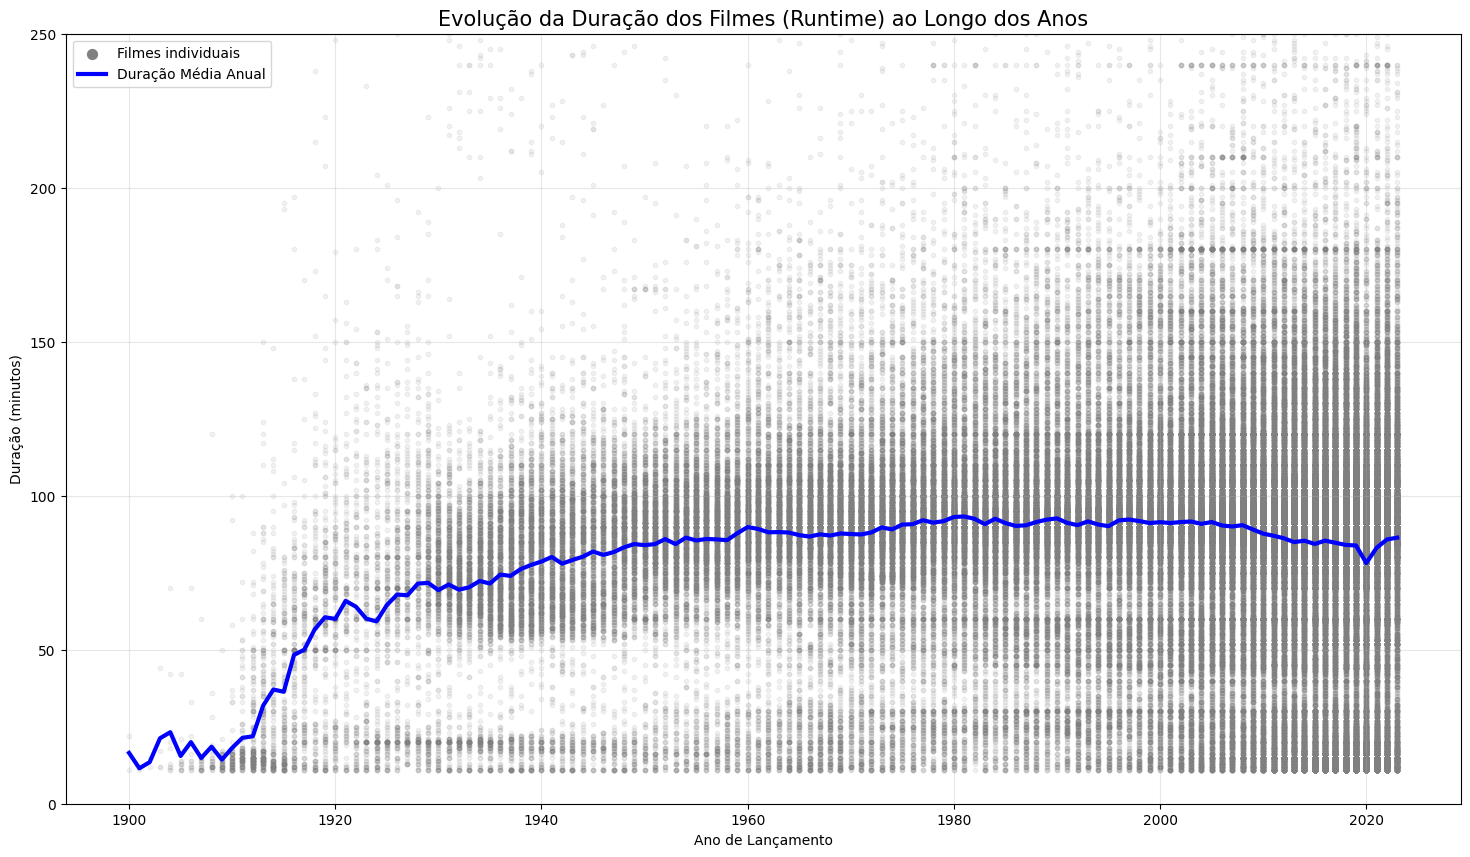

In [66]:
#Exibe um gráfico que mostra a relação entre duração do filme e ano de lançamento

df_aux['release_year'] = pd.to_datetime(df_aux['release_date'], errors='coerce').dt.year
df_aux['release_year'] = pd.to_datetime(df_aux['release_date'], errors='coerce').dt.year

df_runtime = df_aux.dropna(subset=['release_year', 'runtime']).copy()

df_runtime = df_runtime[(df_runtime['release_year'] >= 1900) &
                        (df_runtime['release_year'] <= 2023) &
                        (df_runtime['runtime'] > 10) &
                        (df_runtime['runtime'] < 300)]

df_runtime['release_year'] = df_runtime['release_year'].astype(int)

runtime_medio_ano = df_runtime.groupby('release_year')['runtime'].mean()

plt.figure(figsize=(18, 10))

plt.scatter(df_runtime['release_year'], df_runtime['runtime'],
            alpha=0.1, s=10, color='gray', label='Filmes individuais')

plt.plot(runtime_medio_ano.index, runtime_medio_ano.values,
         color='blue', linewidth=3, label='Duração Média Anual')

plt.title('Evolução da Duração dos Filmes (Runtime) ao Longo dos Anos', fontsize=15)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Duração (minutos)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 250)

lgnd = plt.legend(loc='upper left', scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_alpha(1.0)
    if hasattr(handle, 'set_sizes'):
        handle.set_sizes([50])

plt.show()